### Bonus Solution: Learning Rate Schedulers

In [1]:
# Seting up the environment and importing necessary libraries

import torch
import matplotlib.pyplot as plt

def f(x):
    return x**2

def plot_results(results):
    """
    results should be a dictionary containing one entry for each gradient descent run.
    The entry must also be a tuple in the form (x_history, lr_history).
    """
    plt.figure(figsize = (12,6))
    plt.subplot(1, 2, 1)
    for name, result in results.items():
        plt.plot(result[0], label=name)
    plt.xlabel('Iterations')
    plt.ylabel('x')
    plt.legend()
    plt.title('x vs Iterations')

    plt.subplot(1, 2, 2)
    for name, result in results.items():
        plt.plot(result[1], label=name)
    plt.xlabel('Iterations')
    plt.ylabel('Learning Rate')
    plt.legend()
    plt.title('Learning Rate vs Iterations')

    plt.show()

If we use a constant learning rate, the following problem will appear:
- A large learning rate will cause the model to bounce around the local minima (or even diverge).
- A small learning rate will cause the model to take a long time to train (reach near the local minima).

The function $y= x^2$ is very straightforward to optimize so it’s not that severe (You would notice it never
takes many steps to reach the local minima). However, for more complex models (e.g. neural networks),
both large and small learning rates might cause the issues above. There will eventually be no suitable
constant learning rate.

Adding the learning rate scheduler should be simple:

In [2]:
def optimize(lr_scheduler_class, scheduler_params={}, initial_lr=1.05, num_iterations=20):
    x = torch.tensor(500.0, requires_grad=True)
    x_history = []
    lr_history = []

    optimizer = torch.optim.SGD([x], lr=initial_lr)
    scheduler = lr_scheduler_class(optimizer, **scheduler_params)

    for i in range(num_iterations):
        optimizer.zero_grad()
        loss = f(x)
        loss.backward()
        optimizer.step()

        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(metrics=loss.item())
        else:
            scheduler.step()

        x_history.append(x.item())
        lr_history.append(optimizer.param_groups[0]['lr'])  # Current learning rate

    print(lr_scheduler_class.__name__, x.item())
    return x_history, lr_history


And here is the graph I obtained:

ConstantLR 3363.744384765625
ExponentialLR -6.139762032120188e-10
CosineAnnealingLR -1.6084059097920544e-05
OneCycleLR -0.001113035366870463
ReduceLROnPlateau 1.11700205512234e-18


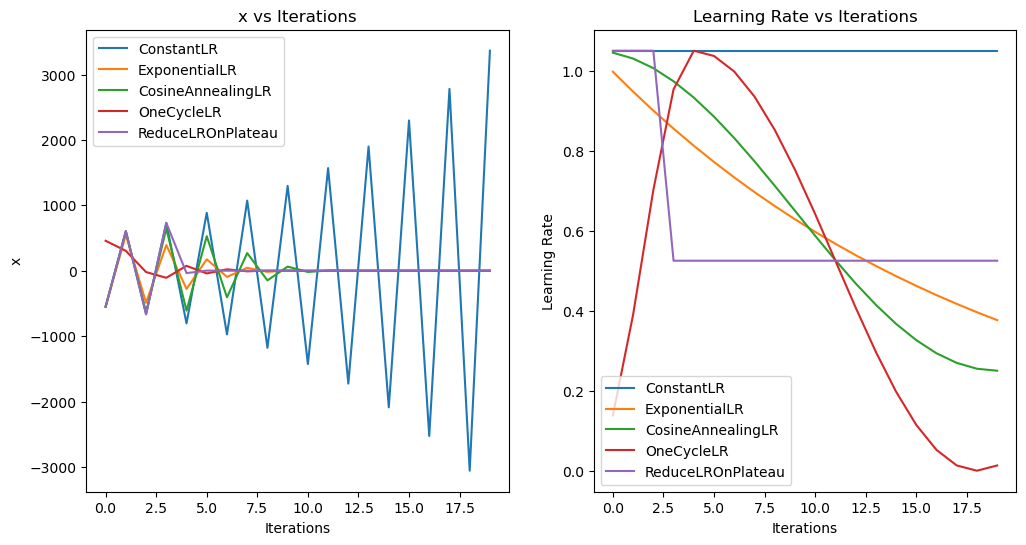

In [3]:
results = {}

results["ConstantLR"] = optimize(torch.optim.lr_scheduler.ConstantLR, {"factor": 1.00, "total_iters": 20})
results["ExponentialLR"] = optimize(torch.optim.lr_scheduler.ExponentialLR, {"gamma": 0.95})
results["CosineAnnealingLR"] = optimize(torch.optim.lr_scheduler.CosineAnnealingLR, {"T_max": 20, "eta_min": 0.25})
results["OneCycleLR"] = optimize(torch.optim.lr_scheduler.OneCycleLR, {"max_lr": 1.05, "total_steps": 20, "max_momentum": 0.2, "base_momentum": 0.2})
results["ReduceLROnPlateau"] = optimize(torch.optim.lr_scheduler.ReduceLROnPlateau, {"mode": "min", "factor": 0.5, "patience": 2})

plot_results(results)

A brief note on how the learning rate schedulers work:
- `StepLR`, `ExponentialLR`, `PolynomialLR`, `CosineAnnealingLR`: These learning rate schedulers decrease the learning rate over epochs based on a fixed schedule. The high learning rate at the start
speeds up training and allows the model to escape local minima, while the learning rate isdecreased
afterwards to help the model to converge. StepLR is more gentle – it only decreases the learning
rate after a fixed number of epochs. ExponentialLR would be much more aggressive, allowing rapid
convergence.
- `CyclicLR`, `OneCycleLR`, `CosineAnnealingWarmRestarts`: These learning rate schedulers decrease
and increase the learning rates periodically. Decreasing the learning rate would help convergence,
while increasing the learning rate would help the model with **exploration** – the model would be
able to escape the local minima to explore other points.
- `ReduceLROnPlateau`: It decreases the learning rate based on performance – when the training /
validation performance never improves for a specified number of epochs. This is the only adaptive
scheduler here (based on model performance).

Understanding the inner workings of the learning rate schedulers is crucial in selecting a good one specific
to the task you’re working on. More importantly, don’t forget to plot out the convergence curve and observe
where the issue lies, before making any decisions.